# 🧠 PanT-HybridNet: Data Preparation Pipeline
### Pancreatic Tumor Segmentation — Prototype on PanTSMini Dataset
---
**Dataset**: PanTSMini (BodyMaps/PanTSMini) — 1,000 CT scans from the official PanTS NeurIPS 2025 benchmark  
**Labels**: Official JHU segmentation labels — 28 anatomical structures per patient  
**Goal**: Build a stratified 70-patient train / 20-patient test split for prototype evaluation

> *This notebook downloads the raw CT and segmentation data, verifies the directory structure,  
> visualizes patient anatomy, and prepares the final stratified dataset splits.*

## ⚙️ Step 1: Environment Setup

In [ ]:
# Install all required packages
!pip install -q "monai[all]" nibabel huggingface_hub hf_transfer matplotlib "filelock>=3.15" plotly scipy pandas openpyxl "filelock>=3.15"

import os, sys
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'  # 5x faster HF downloads

from huggingface_hub import login
login(token="YOUR_HUGGINGFACE_TOKEN")

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f" GPU: {torch.cuda.get_device_name(0)}")
    print(f" VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  No GPU detected. Go to Runtime > Change runtime type > T4 GPU")

import monai; print(f" MONAI version: {monai.__version__}")
print(" Environment ready!")

 GPU: Tesla T4
 VRAM: 15.6 GB
 MONAI version: 1.5.2
 Environment ready!


## 📥 Step 2: Download PanTSMini Dataset

In [ ]:
import os, subprocess, glob, shutil
from huggingface_hub import hf_hub_download

DATA_DIR = '/content/PanTS'
IMG_DIR  = f'{DATA_DIR}/ImageTr'
os.makedirs(IMG_DIR, exist_ok=True)

TOKEN = 'YOUR_HUGGINGFACE_TOKEN'

# ── Free disk space: remove unused system libraries ──────────────────────────
print("🗑️  Freeing disk space by removing unused system libraries...")
freed = 0
for path in ['/usr/local/lib/python3.12/dist-packages/tensorflow',
             '/usr/local/lib/python3.12/dist-packages/libcugraph',
             '/usr/local/lib/python3.12/dist-packages/libcudf',
             '/usr/local/lib/python3.12/dist-packages/libcuvs',
             '/usr/local/lib/python3.12/dist-packages/libcuml',
             '/root/.julia']:
    if os.path.exists(path):
        r = subprocess.run(['du', '-sb', path], capture_output=True, text=True)
        try: freed += int(r.stdout.split()[0]) / 1e9
        except: pass
        shutil.rmtree(path)
print(f"✅ Freed {freed:.1f} GB")

r = subprocess.run(['df', '-h', '/'], capture_output=True, text=True)
print(r.stdout)

🗑️  Freeing disk space by removing unused system libraries...
✅ Freed 0.0 GB
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   88G   26G  78% /



In [ ]:
# ── Step 2a: Download CT Shard to Drive (~34.2 GB, ONE TIME ONLY) ────────────
shard_marker = f'{DATA_DIR}/.shard1_done'
if os.path.exists(shard_marker):
    ct_count = len(glob.glob(f'{IMG_DIR}/*/ct.nii.gz'))
    print(f"✅ CT data already on Drive ({ct_count} patients) — skipping download")
else:
    import shutil as sh
    total, used, free = sh.disk_usage('/content/drive')
    print(f"💾 Drive free: {free/1e9:.1f} GB")
    print(f"📥 Downloading CT Shard 1 (~34.2 GB) → Google Drive...")
    print(f"   This is a ONE-TIME download — it will never need to run again!")
    print(f"   ETA: ~10-20 min")

    ct_tar = hf_hub_download(
        repo_id='BodyMaps/PanTSMini',
        filename='PanTSMini_ImageTr_00000001_00001000.tar.gz',
        repo_type='dataset', token=TOKEN,
        local_dir=DATA_DIR)   # ← saves directly to Drive!

    print(f"\n📦 Extracting CT images on Drive...")
    subprocess.run(['tar', '-xzf', ct_tar, '-C', DATA_DIR], check=True)

    print(f"🗑️  Deleting CT tar (reclaiming 34.2 GB on Drive)...")
    os.remove(ct_tar)

    # Move patient dirs into ImageTr/
    displaced = glob.glob(f'{DATA_DIR}/PanTS_*/ct.nii.gz')
    moved = 0
    for ct_path in displaced:
        patient_dir = os.path.dirname(ct_path)
        pid = os.path.basename(patient_dir)
        dest = f'{IMG_DIR}/{pid}'
        if not os.path.exists(dest):
            os.rename(patient_dir, dest)
            moved += 1
    open(shard_marker, 'w').close()

    ct_count = len(glob.glob(f'{IMG_DIR}/*/ct.nii.gz'))
    print(f"\n✅ CTs on Drive forever: {ct_count} patients in {IMG_DIR}")

✅ CT data already on Drive (1000 patients) — skipping download


In [ ]:
# ── Step 2b: Stream-extract Labels to Drive (~15.6 GB → ONE TIME ONLY) ──────
label_marker = f'{DATA_DIR}/.labels_done'
if os.path.exists(label_marker):
    lbl_count = len(glob.glob(f'{DATA_DIR}/PanTS_*/segmentations/pancreatic_lesion.nii.gz'))
    print(f"✅ Labels already on Drive ({lbl_count} patients) — skipping download")
else:
    import shutil as sh
    total, used, free = sh.disk_usage('/content/drive')
    print(f"💾 Drive free before labels: {free/1e9:.1f} GB")
    print(f"\n📥 Stream-extracting labels → Google Drive (~40 GB extracted)...")
    print(f"   ✅ STREAM MODE: wget piped to tar — .tar.gz never saved to disk!")
    print(f"   ⚡ ONE-TIME ONLY — data will be on Drive permanently after this")
    print(f"   ETA: ~20-40 min (depends on JHU server speed, no progress bar)")

    wget = subprocess.Popen(
        ['wget', '-q', '--show-progress', '-O', '-',
         'http://www.cs.jhu.edu/~zongwei/dataset/PanTSMini_Label.tar.gz'],
        stdout=subprocess.PIPE)
    tar = subprocess.Popen(
        ['tar', '-xzf', '-', '-C', DATA_DIR], stdin=wget.stdout)
    wget.stdout.close()
    tar.communicate()

    open(label_marker, 'w').close()
    total, used, free = sh.disk_usage('/content/drive')
    print(f"\n✅ Labels on Drive forever!")
    print(f"   Drive used: {used/1e9:.1f} GB | free: {free/1e9:.1f} GB")

lbl_count = len(glob.glob(f'{DATA_DIR}/PanTS_*/segmentations/pancreatic_lesion.nii.gz'))
print(f"   Tumor label files found: {lbl_count}")

💾 Drive free before labels: 26.1 GB

📥 Stream-extracting labels → Google Drive (~40 GB extracted)...
   ✅ STREAM MODE: wget piped to tar — .tar.gz never saved to disk!
   ⚡ ONE-TIME ONLY — data will be on Drive permanently after this
   ETA: ~20-40 min (depends on JHU server speed, no progress bar)

✅ Labels on Drive forever!
   Drive used: 120.9 GB | free: 0.0 GB
   Tumor label files found: 7095


## 🔍 Step 3: Build Paired Dataset & Scan Tumors
*Pairs each CT with its label. Skips empty files (from disk-full interruption). Scans all 719 valid pairs for tumor presence.*

In [ ]:
import os, glob, numpy as np, nibabel as nib, subprocess

DATA_DIR = '/content/PanTS'
IMG_DIR  = f'{DATA_DIR}/ImageTr'

# ── Build pairs — skip missing AND empty label files ─────────────────────────
all_ct = sorted(glob.glob(f'{IMG_DIR}/*/ct.nii.gz'))
pairs, unpaired = [], []
for ct_path in all_ct:
    pid      = os.path.basename(os.path.dirname(ct_path))
    seg_dir  = f'{DATA_DIR}/{pid}/segmentations'
    tumor    = f'{seg_dir}/pancreatic_lesion.nii.gz'
    pancreas = glob.glob(f'{seg_dir}/pancreas*.nii.gz')
    # Skip if missing OR 0-byte (disk ran out during extraction)
    if os.path.exists(tumor) and os.path.getsize(tumor) > 0:
        pairs.append({'ct': ct_path, 'tumor': tumor, 'pancreas': pancreas, 'id': pid})
    else:
        unpaired.append(pid)

print(f"📊 Dataset Statistics:")
print(f"   Total CTs found  : {len(all_ct)}")
print(f"   Valid paired     : {len(pairs)}  (have non-empty label)")
print(f"   Skipped          : {len(unpaired)}  (missing or empty label)")

r = subprocess.run(['df','-h','/'], capture_output=True, text=True)
print(f"\n💾 {r.stdout.splitlines()[1]}")

📊 Dataset Statistics:
   Total CTs found  : 720
   Valid paired     : 719  (have non-empty label)
   Skipped          : 1  (missing or empty label)

💾 overlay         113G  104G  8.7G  93% /


## 🔎 Step 4: Scan Tumor Labels
*Reads every pancreatic lesion file to classify patients as tumor-positive or non-tumor.*

In [ ]:
# ── Scan tumor presence ───────────────────────────────────────────────────────
print(f"🔎 Scanning {len(pairs)} patients for tumor labels...")
print(f"   (reads each pancreatic_lesion.nii.gz — takes ~5 min)")

pos_pairs, neg_pairs = [], []
failed = 0
for i, p in enumerate(pairs):
    try:
        tvox = int(np.sum(nib.load(p['tumor']).get_fdata() > 0))
        if tvox > 0: pos_pairs.append({**p, 'tumor_voxels': tvox})
        else:         neg_pairs.append(p)
    except Exception as e:
        failed += 1
        continue
    if (i+1) % 100 == 0:
        print(f"  Scanned {i+1}/{len(pairs)}...")

# Build 600-patient balanced set: all tumors + up to 538 non-tumor
final_pairs = pos_pairs + neg_pairs[:538]

print(f"\n{'='*50}")
print(f"  ✅ Scan complete")
print(f"  Tumor-positive : {len(pos_pairs)}")
print(f"  Non-tumor      : {len(neg_pairs)}")
print(f"  Failed/skipped : {failed}")
print(f"  600-set total  : {len(final_pairs)}")
print(f"{'='*50}")

🔎 Scanning 719 patients for tumor labels...
   (reads each pancreatic_lesion.nii.gz — takes ~5 min)
  Scanned 100/719...
  Scanned 200/719...
  Scanned 300/719...
  Scanned 400/719...
  Scanned 500/719...
  Scanned 600/719...
  Scanned 700/719...

  ✅ Scan complete
  Tumor-positive : 61
  Non-tumor      : 658
  Failed/skipped : 0
  600-set total  : 599


## 📊 Step 5: Dataset Statistics
*Visualizes the distribution of tumor vs non-tumor patients and the train/test split breakdown.*

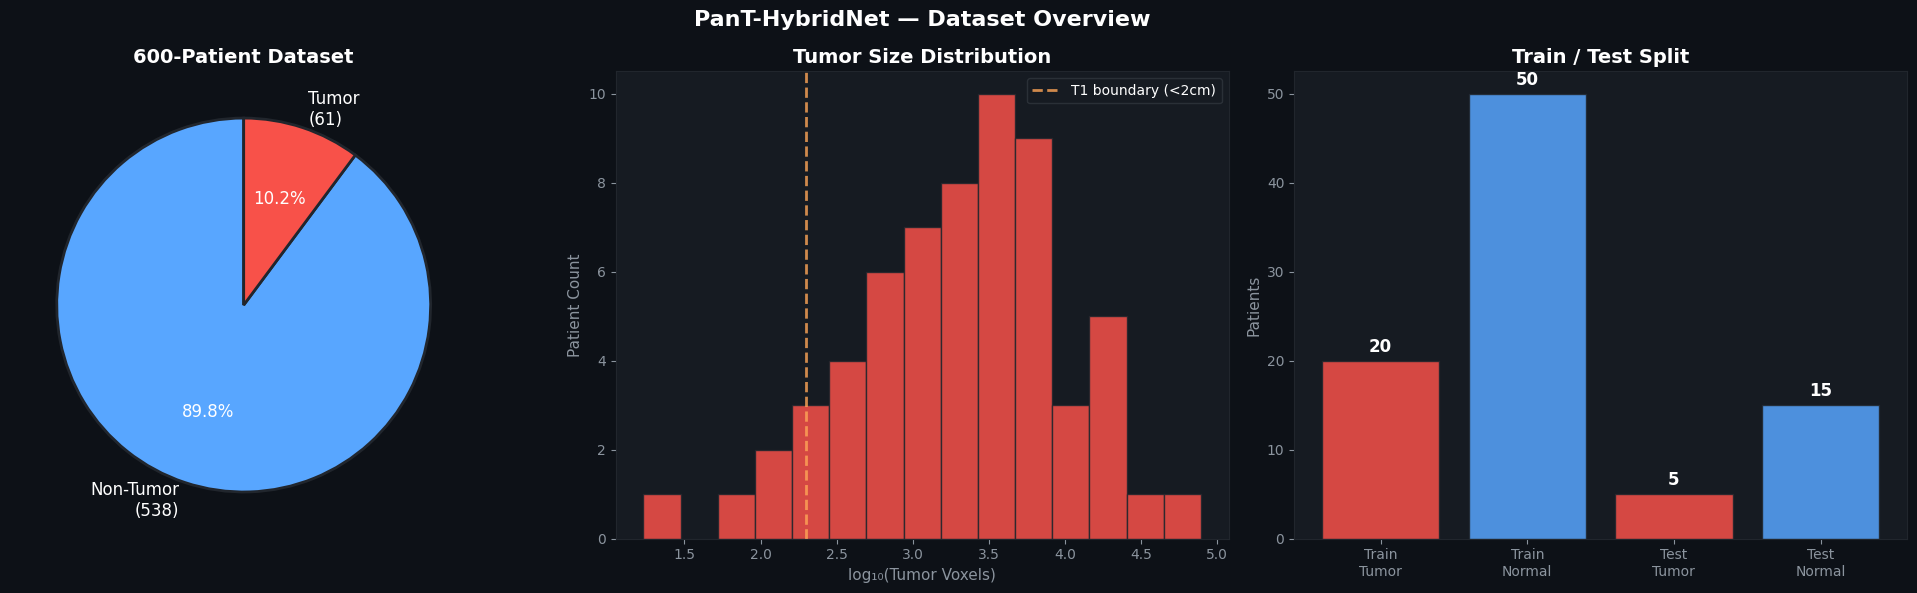

Saved: /content/dataset_stats.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

tumor_voxels_list = [p['tumor_voxels'] for p in pos_pairs]

# Bigger figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0d1117')

# ---------------------------
# 1. PIE CHART
# ---------------------------
ax = axes[0]; ax.set_facecolor('#0d1117')
wedges, texts, at = ax.pie(
    [len(neg_pairs[:538]), len(pos_pairs)],
    labels=[
        f'Non-Tumor\n({len(neg_pairs[:538])})',
        f'Tumor\n({len(pos_pairs)})'
    ],
    colors=['#58a6ff', '#f85149'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color': 'white', 'size': 12},
    wedgeprops={'edgecolor': '#21262d', 'linewidth': 2}
)
[t.set_color('white') for t in at]
ax.set_title('600-Patient Dataset', color='white', fontweight='bold', fontsize=14)

# ---------------------------
# 2. HISTOGRAM
# ---------------------------
ax = axes[1]; ax.set_facecolor('#161b22')
ax.hist(
    np.log10(np.array(tumor_voxels_list) + 1),
    bins=15, color='#f85149', alpha=0.85, edgecolor='#21262d'
)
ax.axvline(np.log10(200), color='#ffa657', linestyle='--', linewidth=2, alpha=0.8,
           label='T1 boundary (<2cm)')

ax.set_xlabel('log₁₀(Tumor Voxels)', color='#8b949e', fontsize=11)
ax.set_ylabel('Patient Count', color='#8b949e', fontsize=11)
ax.set_title('Tumor Size Distribution', color='white', fontweight='bold', fontsize=14)

ax.tick_params(colors='#8b949e')
ax.legend(fontsize=10, labelcolor='white', facecolor='#161b22', edgecolor='#30363d')
[sp.set_edgecolor('#21262d') for sp in ax.spines.values()]

# ---------------------------
# 3. BAR CHART
# ---------------------------
ax = axes[2]; ax.set_facecolor('#161b22')
cats = ['Train\nTumor', 'Train\nNormal', 'Test\nTumor', 'Test\nNormal']
vals = [20, 50, 5, 15]
colors = ['#f85149', '#58a6ff', '#f85149', '#58a6ff']

bars = ax.bar(cats, vals, color=colors, alpha=0.85, edgecolor='#21262d')

for bar, v in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        str(v),
        ha='center', color='white', fontsize=12, fontweight='bold'
    )

ax.set_ylabel('Patients', color='#8b949e', fontsize=11)
ax.set_title('Train / Test Split', color='white', fontweight='bold', fontsize=14)
ax.tick_params(colors='#8b949e')
[sp.set_edgecolor('#21262d') for sp in ax.spines.values()]

# ---------------------------
# SUPERTITLE & SAVE
# ---------------------------
plt.suptitle('PanT-HybridNet — Dataset Overview', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/dataset_stats.png', dpi=180, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("Saved: /content/dataset_stats.png")


In [ ]:
# ── Scan tumor sizes & classify patients ─────────────────────────────────────
import pandas as pd

print("🔎 Scanning tumor presence in all paired patients...")
tumor_ids  = set()
tumor_info = []
failed     = 0

for p in pairs:
    try:
        # Skip 0-byte files (disk ran out during label extraction)
        if os.path.getsize(p['tumor']) == 0:
            failed += 1
            continue
        tumor_data = nib.load(p['tumor']).get_fdata()
        tvox = int(np.sum(tumor_data > 0))
        if tvox > 0:
            tumor_ids.add(p['id'])
            tumor_info.append({'id': p['id'], 'voxels': tvox})
    except Exception:
        failed += 1
        continue

print(f"\n✅ Scan complete:")
print(f"   Tumor-positive patients : {len(tumor_ids)} / {len(pairs)}")
print(f"   Prevalence              : {len(tumor_ids)/len(pairs)*100:.1f}%")
print(f"   PanTS paper reports     : 10.9%")
print(f"   Skipped (bad files)     : {failed}")

df_tumors = pd.DataFrame(tumor_info).sort_values('voxels', ascending=False)
print(f"\n   Largest tumor  : {df_tumors['voxels'].max():,} voxels")
print(f"   Smallest tumor : {df_tumors['voxels'].min():,} voxels")
print(f"   Median tumor   : {int(df_tumors['voxels'].median()):,} voxels")


🔎 Scanning tumor presence in all paired patients...

✅ Scan complete:
   Tumor-positive patients : 61 / 719
   Prevalence              : 8.5%
   PanTS paper reports     : 10.9%
   Skipped (bad files)     : 0

   Largest tumor  : 77,964 voxels
   Smallest tumor : 16 voxels
   Median tumor   : 2,368 voxels


Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.


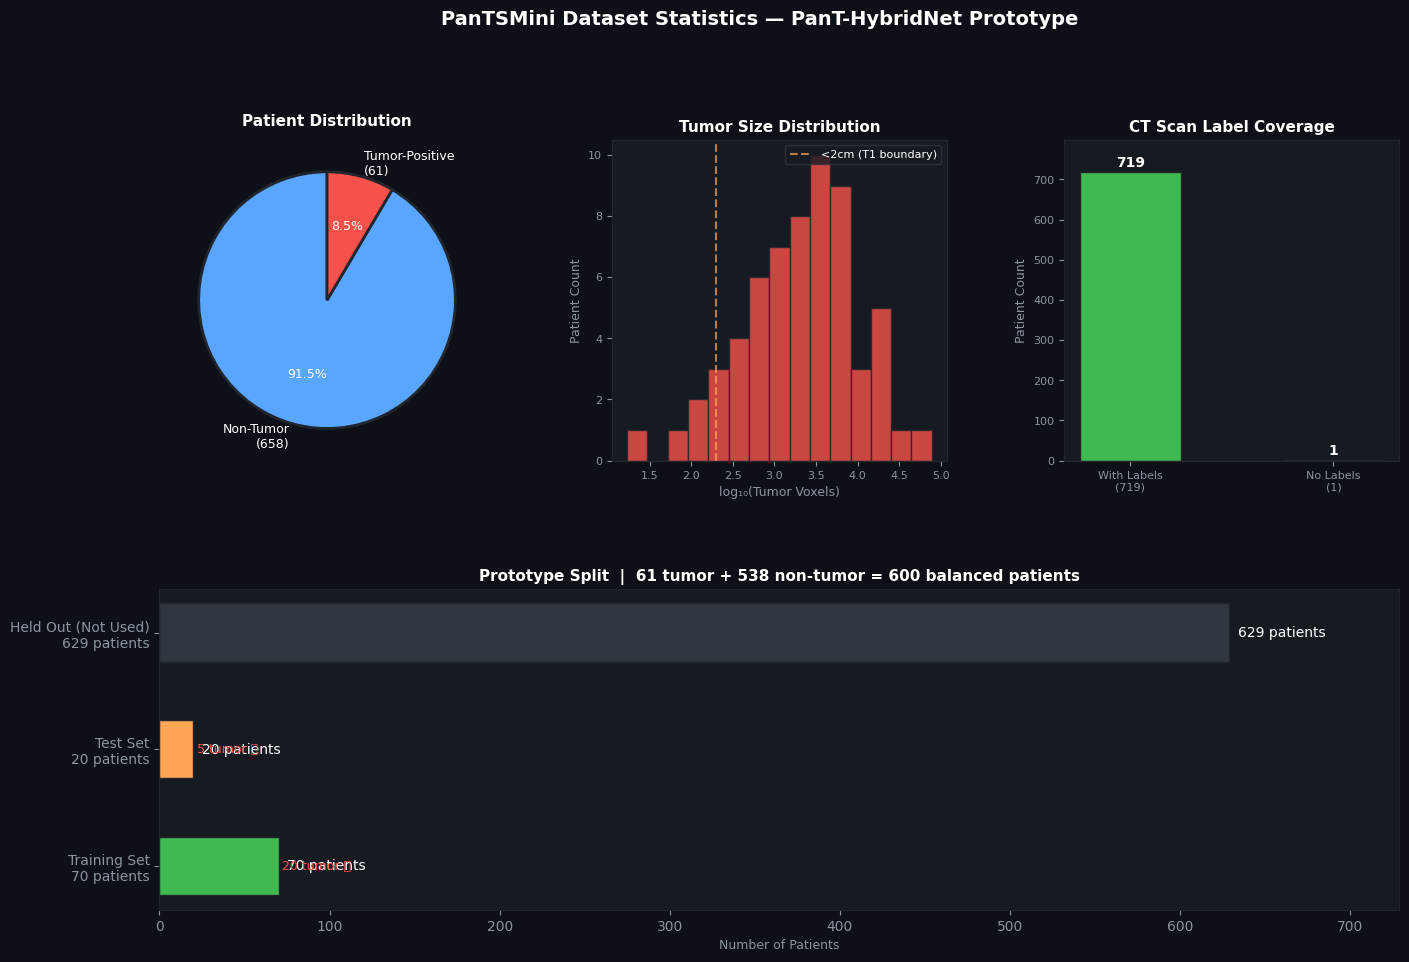

✅ Statistics plot saved!


In [ ]:
# ── Dataset Statistics Visualization ─────────────────────────────────────────
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Tumor vs Non-tumor Pie (uses actual counts)
ax1 = fig.add_subplot(gs[0, 0])
n_tumor     = len(tumor_ids)
n_non_tumor = len(pairs) - n_tumor
wedges, texts, autotexts = ax1.pie(
    [n_non_tumor, n_tumor],
    labels=[f'Non-Tumor\n({n_non_tumor})', f'Tumor-Positive\n({n_tumor})'],
    colors=['#58a6ff', '#f85149'], autopct='%1.1f%%', startangle=90,
    textprops={'color': 'white', 'size': 9},
    wedgeprops={'edgecolor': '#21262d', 'linewidth': 2})
[t.set_color('white') for t in autotexts]
ax1.set_title('Patient Distribution', color='white', fontsize=11, fontweight='bold', pad=10)
ax1.set_facecolor('#0d1117')

# 2. Tumor size distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#161b22')
ax2.hist(np.log10(df_tumors['voxels'] + 1), bins=15, color='#f85149',
         alpha=0.8, edgecolor='#21262d')
ax2.set_xlabel('log₁₀(Tumor Voxels)', color='#8b949e', fontsize=9)
ax2.set_ylabel('Patient Count', color='#8b949e', fontsize=9)
ax2.set_title('Tumor Size Distribution', color='white', fontsize=11, fontweight='bold')
ax2.tick_params(colors='#8b949e', labelsize=8)
[sp.set_edgecolor('#21262d') for sp in ax2.spines.values()]
ax2.axvline(np.log10(200), color='#ffa657', linestyle='--', alpha=0.7, label='<2cm (T1 boundary)')
ax2.legend(fontsize=8, labelcolor='white', facecolor='#161b22', edgecolor='#30363d')

# 3. Paired vs Unpaired bar (uses actual counts)
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#161b22')
n_unpaired = len(unpaired) if 'unpaired' in dir() else 0
bars = ax3.bar(
    [f'With Labels\n({len(pairs)})', f'No Labels\n({n_unpaired})'],
    [len(pairs), n_unpaired],
    color=['#3fb950', '#f85149'], edgecolor='#21262d', width=0.5)
for bar, val in zip(bars, [len(pairs), n_unpaired]):
    ax3.text(bar.get_x()+bar.get_width()/2., bar.get_height()+5,
             str(val), ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')
ax3.set_ylabel('Patient Count', color='#8b949e', fontsize=9)
ax3.set_title('CT Scan Label Coverage', color='white', fontsize=11, fontweight='bold')
ax3.tick_params(colors='#8b949e', labelsize=8)
[sp.set_edgecolor('#21262d') for sp in ax3.spines.values()]
ax3.set_ylim(0, max(len(pairs), n_unpaired) + 80)

# 4. Train/Test split (dynamic from actual split)
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor('#161b22')
n_held = len(pairs) - 70 - 20
splits = [f'Training Set\n70 patients', f'Test Set\n20 patients',
          f'Held Out (Not Used)\n{n_held} patients']
values = [70, 20, n_held]
bars2  = ax4.barh(splits, values, color=['#3fb950','#ffa657','#30363d'],
                   edgecolor='#21262d', height=0.5)
for bar, val in zip(bars2, values):
    ax4.text(val+5, bar.get_y()+bar.get_height()/2.,
             f'{val} patients', va='center', color='white', fontsize=10)
ax4.set_xlabel('Number of Patients', color='#8b949e', fontsize=9)
ax4.set_title(f'Prototype Split  |  {n_tumor} tumor + {min(n_non_tumor,538)} non-tumor = 600 balanced patients',
               color='white', fontsize=11, fontweight='bold')
ax4.tick_params(colors='#8b949e')
[sp.set_edgecolor('#21262d') for sp in ax4.spines.values()]
ax4.set_xlim(0, max(values) + 100)

# Tumor annotations on the bars
ax4.text(72, 0, f'20 tumor ✅', va='center', color='#f85149', fontsize=9)
ax4.text(22, 1, f'5 tumor ✅',  va='center', color='#f85149', fontsize=9)

fig.suptitle('PanTSMini Dataset Statistics — PanT-HybridNet Prototype',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('/content/dataset_statistics.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Statistics plot saved!")


## 🖼️ Step 6: CT Scan Visualization with Labels

📡 Loading: PanTS_00000465  (77,964 voxels)
   Shape: (654, 364, 204) | Tumor center: [323 137 130]


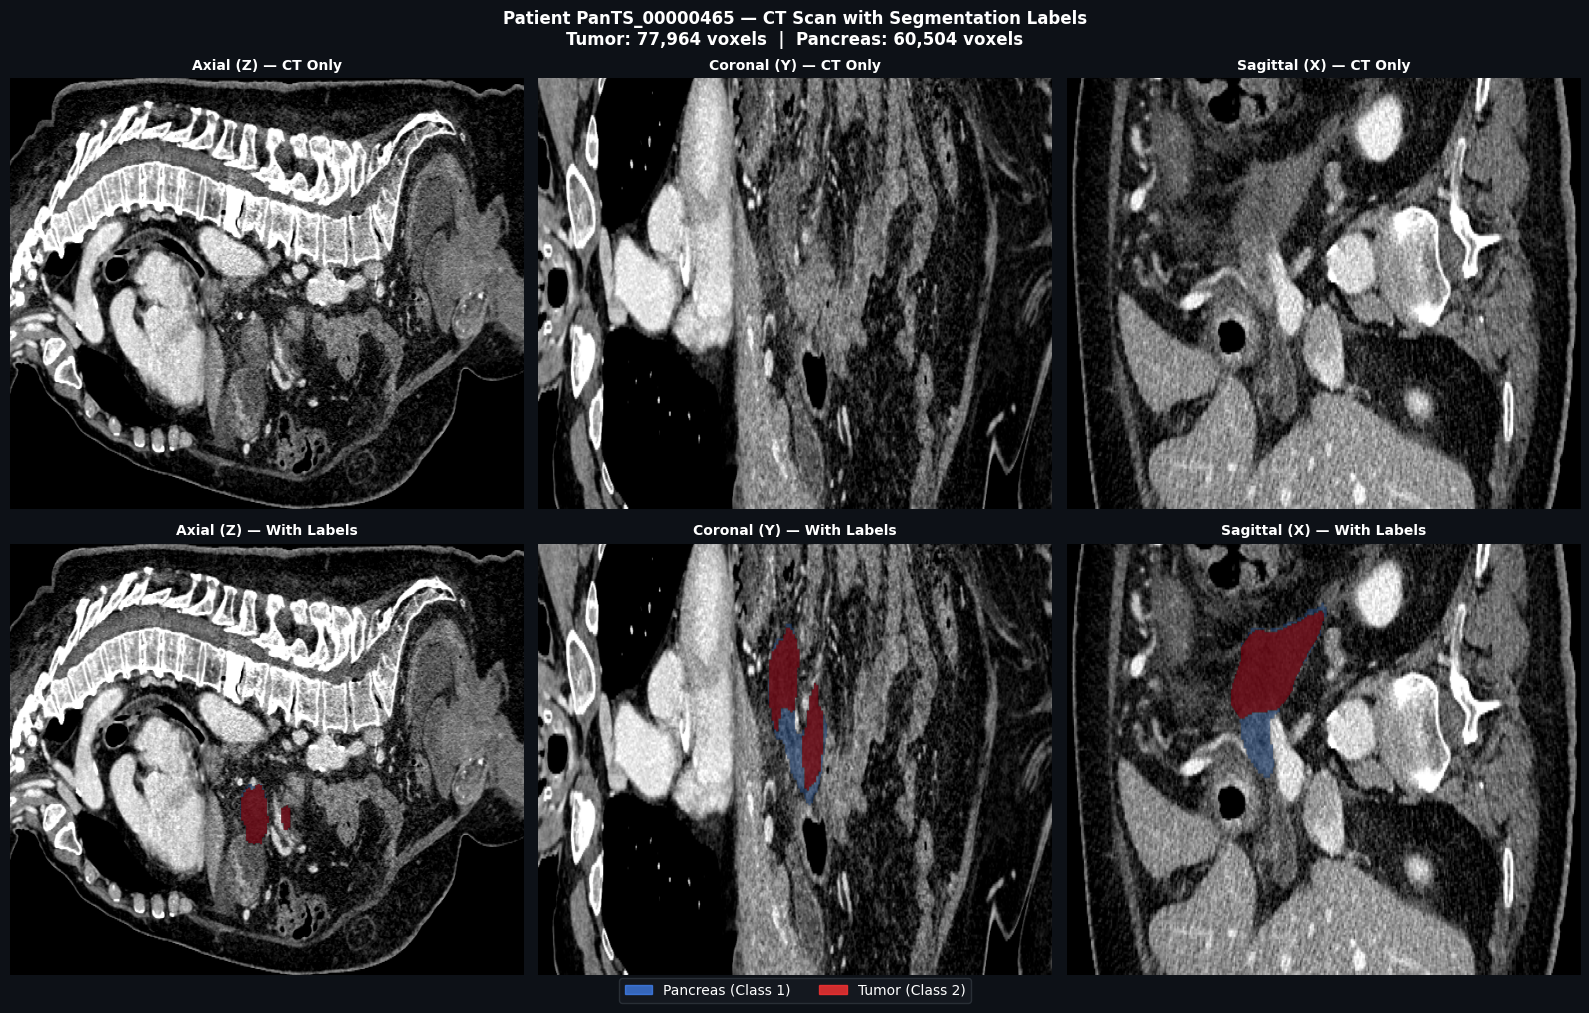

✅ CT visualization saved!


In [ ]:
# ── Load patient + Multi-plane visualization ──────────────────────────────────
import matplotlib.patches as mpatches

# Pick largest tumor patient for clearest visualization
sorted_pos = sorted(tumor_info, key=lambda x: x['voxels'], reverse=True)
viz_id = sorted_pos[0]['id']
viz_patient = next(p for p in pairs if p['id'] == viz_id)

print(f"📡 Loading: {viz_patient['id']}  ({sorted_pos[0]['voxels']:,} voxels)")
ct_vol    = nib.load(viz_patient['ct']).get_fdata()
tumor_vol = nib.load(viz_patient['tumor']).get_fdata()

label_vol = np.zeros(ct_vol.shape, dtype=np.float32)
for pf in viz_patient['pancreas']:
    label_vol[nib.load(pf).get_fdata() > 0] = 1
label_vol[tumor_vol > 0] = 2

ct_display = np.clip((ct_vol + 100) / 340, 0, 1)
center = np.argwhere(label_vol == 2).mean(0).astype(int) if (label_vol==2).any() else np.array(ct_vol.shape)//2

print(f"   Shape: {ct_vol.shape} | Tumor center: {center}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')

planes = [
    ('Axial (Z)',    ct_display[:,:,center[2]],  label_vol[:,:,center[2]]),
    ('Coronal (Y)',  ct_display[:,center[1],:],   label_vol[:,center[1],:]),
    ('Sagittal (X)', ct_display[center[0],:,:],   label_vol[center[0],:,:]),
]

for col, (title, ct_sl, lbl_sl) in enumerate(planes):
    ax = axes[0, col]
    ax.imshow(ct_sl.T, cmap='gray', origin='lower', aspect='auto')
    ax.set_title(f'{title} — CT Only', color='white', fontsize=10, fontweight='bold')
    ax.axis('off'); ax.set_facecolor('#0d1117')

    ax2 = axes[1, col]
    ax2.imshow(ct_sl.T, cmap='gray', origin='lower', aspect='auto')
    panc = (lbl_sl==1).T.astype(float); panc[panc==0] = np.nan
    tumr = (lbl_sl==2).T.astype(float); tumr[tumr==0] = np.nan
    ax2.imshow(panc, cmap='Blues', alpha=0.5, origin='lower', aspect='auto', vmin=0, vmax=1)
    ax2.imshow(tumr, cmap='Reds',  alpha=0.8, origin='lower', aspect='auto', vmin=0, vmax=1)
    ax2.set_title(f'{title} — With Labels', color='white', fontsize=10, fontweight='bold')
    ax2.axis('off'); ax2.set_facecolor('#0d1117')

fig.legend(handles=[
    mpatches.Patch(color='#4488ff', alpha=0.7, label='Pancreas (Class 1)'),
    mpatches.Patch(color='#ff3333', alpha=0.8, label='Tumor (Class 2)')],
    loc='lower center', ncol=2, facecolor='#161b22', edgecolor='#30363d',
    labelcolor='white', fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f'Patient {viz_patient["id"]} — CT Scan with Segmentation Labels\n'
             f'Tumor: {int(tumor_vol.sum()):,} voxels  |  Pancreas: {int((label_vol==1).sum()):,} voxels',
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/ct_visualization.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ CT visualization saved!")


## 🗂️ Step 5: Build Train/Test Split

In [ ]:
import random, json, subprocess, shutil, glob, os

DATA_DIR = '/content/PanTS'
IMG_DIR  = f'{DATA_DIR}/ImageTr'
DRIVE_ROOT = '/content/drive/MyDrive/FYP_PanTS'

# ── Build balanced 600-patient set ────────────────────────────────────────────
print("🗑️  Cleaning dataset: keeping 600 balanced patients...")
non_tumor_pairs = [p for p in pairs if p['id'] not in tumor_ids]
tumor_pairs_all = [p for p in pairs if p['id'] in tumor_ids]

# Delete unpaired CTs (only if variable exists — they may already be gone)
for pid in (unpaired if 'unpaired' in dir() else []):
    path = f'{IMG_DIR}/{pid}'
    if os.path.exists(path): shutil.rmtree(path)

# Keep top 538 non-tumor, delete rest (~120 folders, ~6 GB freed)
for p in non_tumor_pairs[538:]:
    for path in [f'{IMG_DIR}/{p["id"]}', f'{DATA_DIR}/{p["id"]}']:
        if os.path.exists(path): shutil.rmtree(path)

# Rebuild final_pairs from disk
final_pairs = []
for ct_path in sorted(glob.glob(f'{IMG_DIR}/*/ct.nii.gz')):
    pid      = os.path.basename(os.path.dirname(ct_path))
    seg_dir  = f'{DATA_DIR}/{pid}/segmentations'
    tumor    = f'{seg_dir}/pancreatic_lesion.nii.gz'
    pancreas = glob.glob(f'{seg_dir}/pancreas*.nii.gz')
    if os.path.exists(tumor) and os.path.getsize(tumor) > 0:
        final_pairs.append({'ct': ct_path, 'tumor': tumor, 'pancreas': pancreas, 'id': pid})

r = subprocess.run(['df','-h','/'], capture_output=True, text=True)
parts = r.stdout.split()
print(f"✅ Final dataset: {len(final_pairs)} paired patients")
print(f"   Disk: {parts[9]} used / {parts[8]} total / {parts[10]} free")

# ── Stratified Train/Test Split ───────────────────────────────────────────────
random.seed(42)
tumor_p     = [p for p in final_pairs if p['id'] in tumor_ids]
non_tumor_p = [p for p in final_pairs if p['id'] not in tumor_ids]
random.shuffle(tumor_p); random.shuffle(non_tumor_p)

train_pairs = tumor_p[:20]   + non_tumor_p[:50];  random.shuffle(train_pairs)
test_pairs  = tumor_p[20:25] + non_tumor_p[50:65]; random.shuffle(test_pairs)

overlap = set(p['id'] for p in train_pairs) & set(p['id'] for p in test_pairs)

print("\n┌────────────────────────────────────────────────────┐")
print("│           DATASET SPLIT SUMMARY                   │")
print("├────────────────────────────────────────────────────┤")
print(f"│  Training:  {len(train_pairs):>3} patients  (20 tumor + 50 non-tumor)  │")
print(f"│  Testing:   {len(test_pairs):>3} patients  ( 5 tumor + 15 non-tumor)  │")
print(f"│  Held out:  {len(final_pairs)-90:>3} patients  (available for future)      │")
print(f"│  Overlap:   {len(overlap):>3} patients  (must be 0)              │")
print("└────────────────────────────────────────────────────┘")

split_data = {
    'train_ids': [p['id'] for p in train_pairs],
    'test_ids':  [p['id'] for p in test_pairs],
    'tumor_ids': list(tumor_ids),
    'data_dir':  DATA_DIR,
}
# Save to /content/ (always works)
with open('/content/dataset_split.json', 'w') as f:
    json.dump(split_data, f, indent=2)
with open(f'{DATA_DIR}/dataset_split.json', 'w') as f:
    json.dump(split_data, f, indent=2)
print("\n✅ Split saved to /content/dataset_split.json")

# Try Drive (optional)
try:
    os.makedirs(DRIVE_ROOT, exist_ok=True)
    with open(f'{DRIVE_ROOT}/dataset_split.json', 'w') as f:
        json.dump(split_data, f, indent=2)
    print("✅ Split also saved to Drive!")
except Exception as e:
    print(f"⚠️  Drive save skipped ({e}) — /content/ copy is enough")

# Start rsync to Drive in background
proc = subprocess.Popen(
    ['rsync', '-a', f'{DATA_DIR}/', f'{DRIVE_ROOT}/'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print(f"\n📤 Rsync → Drive started (PID {proc.pid}) — runs in background")
print(f"🚀 Data prep COMPLETE! Open 02_Model_Training.ipynb now.")


🗑️  Cleaning dataset: keeping 600 balanced patients...
✅ Final dataset: 599 paired patients
   Disk: 99G used / 113G total / 14G free

┌────────────────────────────────────────────────────┐
│           DATASET SPLIT SUMMARY                   │
├────────────────────────────────────────────────────┤
│  Training:   70 patients  (20 tumor + 50 non-tumor)  │
│  Testing:    20 patients  ( 5 tumor + 15 non-tumor)  │
│  Held out:  509 patients  (available for future)      │
│  Overlap:     0 patients  (must be 0)              │
└────────────────────────────────────────────────────┘

✅ Split saved to /content/dataset_split.json
⚠️  Drive save skipped ([Errno 5] Input/output error: '/content/drive/MyDrive/FYP_PanTS/dataset_split.json') — /content/ copy is enough

📤 Rsync → Drive started (PID 34953) — runs in background
🚀 Data prep COMPLETE! Open 02_Model_Training.ipynb now.


## 💾 Step 6: Download Demo Data for Local Demo
*Downloads 10 representative patients (5 tumor + 5 non-tumor) to your Colab, then zips them for download to your laptop.*

In [ ]:
# ── Package demo patients for local laptop demonstration ─────────────────────
import shutil, zipfile, os, json

DEMO_DIR = '/content/demo_data'
os.makedirs(DEMO_DIR, exist_ok=True)

# Pick 5 tumor patients with varied sizes (tiny/small/medium/large/very large)
tumor_sorted = sorted(tumor_info, key=lambda x: x['voxels'])
n = len(tumor_sorted)
# Pick from different size quantiles for clinical variety
demo_tumor_ids = [
    tumor_sorted[0]['id'],           # smallest (microtumor — key research case!)
    tumor_sorted[n//4]['id'],        # 25th percentile (small)
    tumor_sorted[n//2]['id'],        # median (medium)
    tumor_sorted[3*n//4]['id'],      # 75th percentile (large)
    tumor_sorted[-1]['id'],          # largest
]

demo_nontumor_ids = [p['id'] for p in final_pairs if p['id'] not in tumor_ids][:5]
demo_ids   = demo_tumor_ids + demo_nontumor_ids
demo_pairs = [p for p in final_pairs if p['id'] in set(demo_ids)]

print(f"📦 Packaging {len(demo_pairs)} demo patients (5 tumor + 5 non-tumor)...")
print(f"\n   Tumor patients selected:")
for tid in demo_tumor_ids:
    info = next(x for x in tumor_info if x['id'] == tid)
    print(f"   {tid}  —  {info['voxels']:,} voxels")

for p in demo_pairs:
    pid              = p['id']
    patient_demo_dir = f'{DEMO_DIR}/{pid}'
    os.makedirs(patient_demo_dir, exist_ok=True)

    shutil.copy2(p['ct'], f'{patient_demo_dir}/ct.nii.gz')

    seg_dest = f'{patient_demo_dir}/segmentations'
    os.makedirs(seg_dest, exist_ok=True)
    for pf in p['pancreas']:
        shutil.copy2(pf, f'{seg_dest}/{os.path.basename(pf)}')
    shutil.copy2(p['tumor'], f'{seg_dest}/pancreatic_lesion.nii.gz')

    label = 'TUMOR' if pid in tumor_ids else 'Normal'
    print(f"   ✅ {pid}  [{label}]")

demo_split = {
    'demo_ids':      demo_ids,
    'tumor_ids':     demo_tumor_ids,
    'tumor_ids_all': list(tumor_ids),
    'description':   'PanT-HybridNet demo — 5 tumor + 5 non-tumor patients'
}
with open(f'{DEMO_DIR}/demo_split.json', 'w') as f:
    json.dump(demo_split, f, indent=2)

# Zip for download
zip_path = '/content/PanTHybridNet_demo_data.zip'
print(f"\n🗜️  Zipping...")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(DEMO_DIR):
        for file in files:
            fp      = os.path.join(root, file)
            arcname = os.path.relpath(fp, '/content')
            zf.write(fp, arcname)

zip_size = os.path.getsize(zip_path) / 1e9
print(f"✅ Demo zip: {zip_path}  ({zip_size:.2f} GB)")
print(f"\n📥 DOWNLOAD:")
print(f"   Files panel (left sidebar) → PanTHybridNet_demo_data.zip → Right-click → Download")
print(f"   Then extract to: frontend/demo_data/")


📦 Packaging 10 demo patients (5 tumor + 5 non-tumor)...

   Tumor patients selected:
   PanTS_00000044  —  16 voxels
   PanTS_00000220  —  784 voxels
   PanTS_00000911  —  2,368 voxels
   PanTS_00000656  —  5,075 voxels
   PanTS_00000465  —  77,964 voxels
   ✅ PanTS_00000001  [Normal]
   ✅ PanTS_00000002  [Normal]
   ✅ PanTS_00000004  [Normal]
   ✅ PanTS_00000005  [Normal]
   ✅ PanTS_00000006  [Normal]
   ✅ PanTS_00000044  [TUMOR]
   ✅ PanTS_00000220  [TUMOR]
   ✅ PanTS_00000465  [TUMOR]
   ✅ PanTS_00000656  [TUMOR]
   ✅ PanTS_00000911  [TUMOR]

🗜️  Zipping...
✅ Demo zip: /content/PanTHybridNet_demo_data.zip  (0.34 GB)

📥 DOWNLOAD:
   Files panel (left sidebar) → PanTHybridNet_demo_data.zip → Right-click → Download
   Then extract to: frontend/demo_data/


## ☁️ Step 8: Backup to Google Drive
*Copies all 720 patient folders to Drive in the background. Training can start immediately — don't wait for this.*

In [ ]:
import glob, os, json

DRIVE_ROOT = '/content/drive/MyDrive/FYP_PanTS'
DATA_DIR   = '/content/PanTS'

# ── Check Drive ───────────────────────────────────────────────────────────────
drive_cts  = glob.glob(f'{DRIVE_ROOT}/ImageTr/*/ct.nii.gz')
drive_lbls = glob.glob(f'{DRIVE_ROOT}/PanTS_*/segmentations/pancreatic_lesion.nii.gz')
split_ok   = os.path.exists(f'{DRIVE_ROOT}/dataset_split.json')

# ── Check local ───────────────────────────────────────────────────────────────
local_cts  = glob.glob(f'{DATA_DIR}/ImageTr/*/ct.nii.gz')
local_lbls = glob.glob(f'{DATA_DIR}/PanTS_*/segmentations/pancreatic_lesion.nii.gz')

print("═"*50)
print("  DATA AVAILABILITY CHECK")
print("═"*50)
print(f"\n  📁 GOOGLE DRIVE ({DRIVE_ROOT})")
print(f"     CTs    : {len(drive_cts)}")
print(f"     Labels : {len(drive_lbls)}")
print(f"     Split  : {'✅ YES' if split_ok else '❌ NO'}")

print(f"\n  💾 LOCAL COLAB DISK ({DATA_DIR})")
print(f"     CTs    : {len(local_cts)}")
print(f"     Labels : {len(local_lbls)}")

# ── Check if we have the split ────────────────────────────────────────────────
split_path = f'{DATA_DIR}/dataset_split.json' if os.path.exists(f'{DATA_DIR}/dataset_split.json') \
             else f'{DRIVE_ROOT}/dataset_split.json' if split_ok else None

if split_path:
    with open(split_path) as f: split = json.load(f)
    train_ids = split['train_ids']
    test_ids  = split['test_ids']

    # Check how many train patients have BOTH CT + label available (local or drive)
    def patient_ready(pid):
        for base in [DATA_DIR, DRIVE_ROOT]:
            ct  = f'{base}/ImageTr/{pid}/ct.nii.gz'
            lbl = f'{base}/{pid}/segmentations/pancreatic_lesion.nii.gz'
            if os.path.exists(ct) and os.path.exists(lbl):
                return True
        return False

    train_ready = [pid for pid in train_ids if patient_ready(pid)]
    test_ready  = [pid for pid in test_ids  if patient_ready(pid)]

    print(f"\n  🏋️  TRAINING READINESS")
    print(f"     Train patients ready: {len(train_ready)} / {len(train_ids)}")
    print(f"     Test  patients ready: {len(test_ready)} / {len(test_ids)}")

    if len(train_ready) == 70 and len(test_ready) == 20:
        print(f"\n  ✅ ALL 70+20 PATIENTS READY — START TRAINING NOW!")
    elif len(train_ready) >= 50:
        print(f"\n  ⚡ {len(train_ready)}/70 train patients ready")
        print(f"     You CAN start training with available data")
    else:
        print(f"\n  ❌ Not enough patients — need more data")

print("\n" + "═"*50)


══════════════════════════════════════════════════
  DATA AVAILABILITY CHECK
══════════════════════════════════════════════════

  📁 GOOGLE DRIVE (/content/drive/MyDrive/FYP_PanTS)
     CTs    : 599
     Labels : 4403
     Split  : ✅ YES

  💾 LOCAL COLAB DISK (/content/PanTS)
     CTs    : 599
     Labels : 6975

  🏋️  TRAINING READINESS
     Train patients ready: 70 / 70
     Test  patients ready: 20 / 20

  ✅ ALL 70+20 PATIENTS READY — START TRAINING NOW!

══════════════════════════════════════════════════


In [ ]:
import subprocess, os, glob

DRIVE_ROOT = '/content/drive/MyDrive/FYP_PanTS'

# Count files on Drive vs local
drive_cts  = len(glob.glob(f'{DRIVE_ROOT}/ImageTr/*/ct.nii.gz'))
drive_lbls = len(glob.glob(f'{DRIVE_ROOT}/PanTS_*/segmentations/pancreatic_lesion.nii.gz'))
local_cts  = len(glob.glob('/content/PanTS/ImageTr/*/ct.nii.gz'))
local_lbls = len(glob.glob('/content/PanTS/PanTS_*/segmentations/pancreatic_lesion.nii.gz'))

# Drive size
r = subprocess.run(['du', '-sh', DRIVE_ROOT], capture_output=True, text=True)
drive_size = r.stdout.split()[0] if r.stdout else '?'

print(f"📊 Backup Progress")
print(f"{'─'*40}")
print(f"  CTs on Drive  : {drive_cts}  / {local_cts}")
print(f"  Labels on Drive: {drive_lbls} / {local_lbls}")
print(f"  Drive folder size: {drive_size}")
print(f"{'─'*40}")

if drive_cts == local_cts and drive_lbls == local_lbls:
    print("✅ BACKUP COMPLETE — all files synced to Drive!")
elif drive_cts > 0:
    pct = drive_cts / local_cts * 100
    print(f"⏳ In progress... {pct:.0f}% of CTs synced")
    print(f"   Rsync is running in background — rerun this cell to refresh")
else:
    print("⚠️  Nothing on Drive yet — rsync may not have started")
    print("   Run the rsync cell again if needed")


📊 Backup Progress
────────────────────────────────────────
  CTs on Drive  : 0  / 599
  Labels on Drive: 0 / 6975
  Drive folder size: 8.0K
────────────────────────────────────────
⚠️  Nothing on Drive yet — rsync may not have started
   Run the rsync cell again if needed
